# OvercookedV2 Environment Demo

This notebook demonstrates how to create and inspect the OvercookedV2 environment, including state and observations.


In [1]:
import jax
import jax.numpy as jnp
from jaxmarl import make
from jaxmarl.environments.overcooked_v2 import overcooked_v2_layouts

# Set random seed for reproducibility
key = jax.random.PRNGKey(42)


Importing submoduled environments...
Submoduled environments not found. Skipping import.


## Create the Environment

We'll create an OvercookedV2 environment with a simple layout. Available layouts include:
- `cramped_room`: A small room layout
- `asymm_advantages`: Asymmetric advantages layout
- `coord_ring`: Coordination ring layout
- And more...

You can also configure:
- `agent_view_size`: Number of blocks the agent can view (None for full observability, or set to an integer (e.g., 2))
- `max_steps`: Maximum number of steps per episode
- `random_agent_positions`: Whether to randomize agent starting positions


In [2]:
# Create the environment
env = make(
    "overcooked_v2",
    layout="cramped_room",  # You can use any layout from overcooked_v2_layouts
    max_steps=400,
    agent_view_size=None,  # None means full observability, or set to an integer (e.g., 2)
    random_agent_positions=False,
)

print(f"Environment created successfully!")
print(f"Number of agents: {env.num_agents}")
print(f"Agents: {env.agents}")
print(f"Grid size: {env.width} x {env.height}")
print(f"Max steps: {env.max_steps}")


Environment created successfully!
Number of agents: 2
Agents: ['agent_0', 'agent_1']
Grid size: 5 x 4
Max steps: 400


## Reset the Environment

Reset the environment to get the initial state and observations.


In [3]:
# Reset the environment
key, reset_key = jax.random.split(key)
obs, state = env.reset(reset_key)

print("Environment reset successfully!")
print(f"Observation keys: {list(obs.keys())}")


Environment reset successfully!
Observation keys: ['agent_0', 'agent_1']


## Display State Information

The state contains all the information about the current environment state.


In [4]:
print("=== STATE INFORMATION ===")
print(f"\nTime step: {state.time}")
print(f"Terminal: {state.terminal}")
print(f"Current recipe: {state.recipe}")
print(f"New correct delivery: {state.new_correct_delivery}")

print("\n=== AGENT INFORMATION ===")
for i, agent_name in enumerate(env.agents):
    print(f"\n{agent_name}:")
    print(f"  Position: ({state.agents.pos.x[i]}, {state.agents.pos.y[i]})")
    print(f"  Direction: {state.agents.dir[i]}")
    print(f"  Inventory: {state.agents.inventory[i]}")

print("\n=== GRID INFORMATION ===")
print(f"Grid shape: {state.grid.shape}")
print(f"Grid dtype: {state.grid.dtype}")
print("\nGrid structure:")
print("  Channel 0: Static objects (walls, counters, pots, etc.)")
print("  Channel 1: Dynamic items (plates, ingredients)")
print("  Channel 2: Extra info (recipe indicators, etc.)")


=== STATE INFORMATION ===

Time step: 0
Terminal: False
Current recipe: 12
New correct delivery: False

=== AGENT INFORMATION ===

agent_0:
  Position: (3, 1)
  Direction: 0
  Inventory: 0

agent_1:
  Position: (1, 1)
  Direction: 0
  Inventory: 0

=== GRID INFORMATION ===
Grid shape: (4, 5, 3)
Grid dtype: int32

Grid structure:
  Channel 0: Static objects (walls, counters, pots, etc.)
  Channel 1: Dynamic items (plates, ingredients)
  Channel 2: Extra info (recipe indicators, etc.)


## Display Observations

Observations are what each agent can see. The observation shape depends on `agent_view_size`:
- If `agent_view_size=None`: Full grid observability
- If `agent_view_size=N`: Partial observability with N blocks visible in each direction


In [ ]:
print("=== OBSERVATIONS ===")
for agent_name in env.agents:
    agent_obs = obs[agent_name]
    print(f"\n{agent_name} observation:")
    print(f"  Shape: {agent_obs.shape}")
    print(f"  Dtype: {agent_obs.dtype}")
    print(f"  Min value: {jnp.min(agent_obs)}")
    print(f"  Max value: {jnp.max(agent_obs)}")
    print(f"  Mean value: {jnp.mean(agent_obs):.4f}")


=== OBSERVATIONS ===

agent_0 observation:
  Shape: (4, 5, 30)
  Dtype: int32
  Min value: 0
  Max value: 1
  Mean value: 0.0300

agent_1 observation:
  Shape: (4, 5, 30)
  Dtype: int32
  Min value: 0
  Max value: 1
  Mean value: 0.0300


: 

## Visualize Grid Channels

Let's visualize the different channels of the grid to understand what's in the environment.


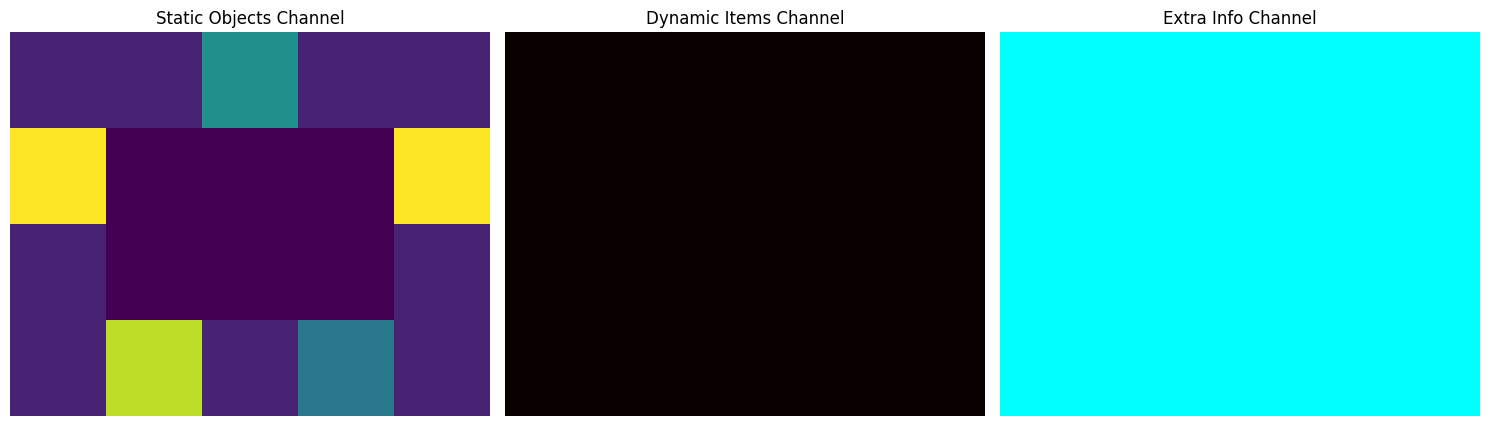

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Extract grid channels
static_channel = np.array(state.grid[:, :, 0])
dynamic_channel = np.array(state.grid[:, :, 1])
extra_channel = np.array(state.grid[:, :, 2])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(static_channel, cmap='viridis')
axes[0].set_title('Static Objects Channel')
axes[0].axis('off')

axes[1].imshow(dynamic_channel, cmap='hot')
axes[1].set_title('Dynamic Items Channel')
axes[1].axis('off')

axes[2].imshow(extra_channel, cmap='cool')
axes[2].set_title('Extra Info Channel')
axes[2].axis('off')

plt.tight_layout()
plt.show()


## Visualize Agent Observations

Visualize what each agent sees in their observation.


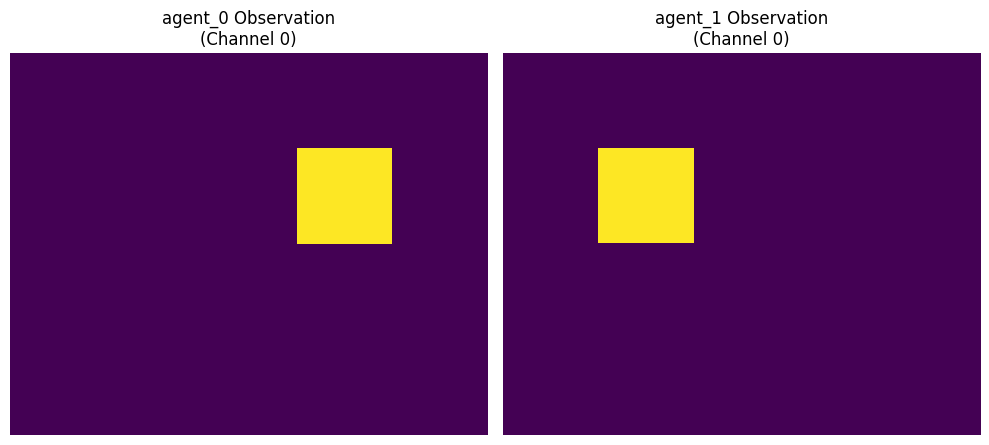

In [7]:
fig, axes = plt.subplots(1, len(env.agents), figsize=(5 * len(env.agents), 5))

if len(env.agents) == 1:
    axes = [axes]

for idx, agent_name in enumerate(env.agents):
    agent_obs = np.array(obs[agent_name])
    
    # If observation has multiple channels, show them
    if len(agent_obs.shape) == 3:
        # Show first channel as example
        axes[idx].imshow(agent_obs[:, :, 0], cmap='viridis')
        axes[idx].set_title(f'{agent_name} Observation\n(Channel 0)')
    else:
        axes[idx].imshow(agent_obs, cmap='viridis')
        axes[idx].set_title(f'{agent_name} Observation')
    
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


## Available Layouts

Let's see what layouts are available in OvercookedV2.


In [8]:
print("Available OvercookedV2 layouts:")
for layout_name in sorted(overcooked_v2_layouts.keys()):
    layout = overcooked_v2_layouts[layout_name]
    print(f"  - {layout_name}: {layout.width}x{layout.height} grid, {len(layout.agent_positions)} agents")


Available OvercookedV2 layouts:
  - asymm_advantages: 9x5 grid, 2 agents
  - asymm_advantages_recipes_center: 9x5 grid, 2 agents
  - asymm_advantages_recipes_left: 9x5 grid, 2 agents
  - asymm_advantages_recipes_right: 9x5 grid, 2 agents
  - coord_ring: 5x5 grid, 2 agents
  - counter_circuit: 8x5 grid, 2 agents
  - cramped_room: 5x4 grid, 2 agents
  - cramped_room_v2: 5x4 grid, 2 agents
  - demo_cook_simple: 11x5 grid, 2 agents
  - demo_cook_wide: 11x6 grid, 2 agents
  - forced_coord: 5x5 grid, 2 agents
  - fun_coordination: 9x5 grid, 2 agents
  - fun_symmetries: 7x5 grid, 2 agents
  - fun_symmetries1: 8x5 grid, 2 agents
  - fun_symmetries_plates: 7x5 grid, 2 agents
  - grounded_coord_ring: 9x9 grid, 2 agents
  - grounded_coord_simple: 8x5 grid, 2 agents
  - long_room: 15x4 grid, 1 agents
  - more_fun_coordination: 9x6 grid, 2 agents
  - test_time_simple: 8x5 grid, 2 agents
  - test_time_wide: 6x7 grid, 2 agents
  - two_rooms: 9x5 grid, 2 agents
  - two_rooms_both: 9x5 grid, 2 agents


## Take a Step

Let's take a step in the environment with random actions to see how state and observations change.


In [9]:
# Sample random actions for each agent
key, step_key = jax.random.split(key)
step_key = jax.random.split(step_key, env.num_agents)
actions = {
    agent: env.action_space(agent).sample(step_key[i])
    for i, agent in enumerate(env.agents)
}

print("Actions taken:")
for agent, action in actions.items():
    print(f"  {agent}: {action}")

# Step the environment
key, step_key = jax.random.split(key)
obs_new, state_new, rewards, dones, infos = env.step(step_key, state, actions)

print("\n=== AFTER STEP ===")
print(f"Time step: {state_new.time}")
print(f"Rewards: {rewards}")
print(f"Dones: {dones}")
print(f"\nAgent positions after step:")
for i, agent_name in enumerate(env.agents):
    print(f"  {agent_name}: ({state_new.agents.pos.x[i]}, {state_new.agents.pos.y[i]})")


Actions taken:
  agent_0: 0
  agent_1: 3

=== AFTER STEP ===
Time step: 1
Rewards: {'agent_0': Array(0., dtype=float32, weak_type=True), 'agent_1': Array(0., dtype=float32, weak_type=True)}
Dones: {'__all__': Array(False, dtype=bool), 'agent_0': Array(False, dtype=bool), 'agent_1': Array(False, dtype=bool)}

Agent positions after step:
  agent_0: (3, 1)
  agent_1: (1, 1)


## Visualize Agent Movement

Collect a trajectory and visualize the agent movement using animation, similar to the MPE visualization example.


In [11]:
%matplotlib inline

import matplotlib.animation as animation
import numpy as np
from jaxmarl.viz.overcooked_v2_visualizer import OvercookedV2Visualizer
from IPython.display import HTML

# Parameters + random keys
max_steps = 50
key = jax.random.PRNGKey(42)
key, key_r, key_a = jax.random.split(key, 3)

# Reset environment for visualization
obs, state = env.reset(key_r)
print('List of agents in environment:', env.agents)

# Collect trajectory
state_seq = []
for step in range(max_steps):
    state_seq.append(state)
    # Iterate random keys and sample actions
    key, key_s, key_a = jax.random.split(key, 3)
    key_a = jax.random.split(key_a, env.num_agents)
    actions = {agent: env.action_space(agent).sample(key_a[i]) for i, agent in enumerate(env.agents)}

    # Step environment
    obs, state, rewards, dones, infos = env.step(key_s, state, actions)
    
    # Stop if episode is done
    if state.terminal or jnp.any(jnp.array(list(dones.values()))):
        break

print(f'Collected {len(state_seq)} states for visualization')


List of agents in environment: ['agent_0', 'agent_1']
Collected 50 states for visualization


In [12]:
# Stack states into a batched state for vmap
# jax.vmap expects a pytree where each leaf is batched along the first dimension
from jax import tree_util

# Convert list of states to batched state
def stack_states(state_list):
    """Stack a list of states into a batched state for vmap"""
    return tree_util.tree_map(lambda *xs: jnp.stack(xs), *state_list)

batched_state = stack_states(state_seq)

# Create visualizer and render sequence
viz = OvercookedV2Visualizer()
frame_seq = viz.render_sequence(batched_state, agent_view_size=None)

# Convert to numpy for matplotlib
frame_seq = np.array(frame_seq)
print(f"Frame sequence shape: {frame_seq.shape}")


Frame sequence shape: (50, 128, 160, 3)


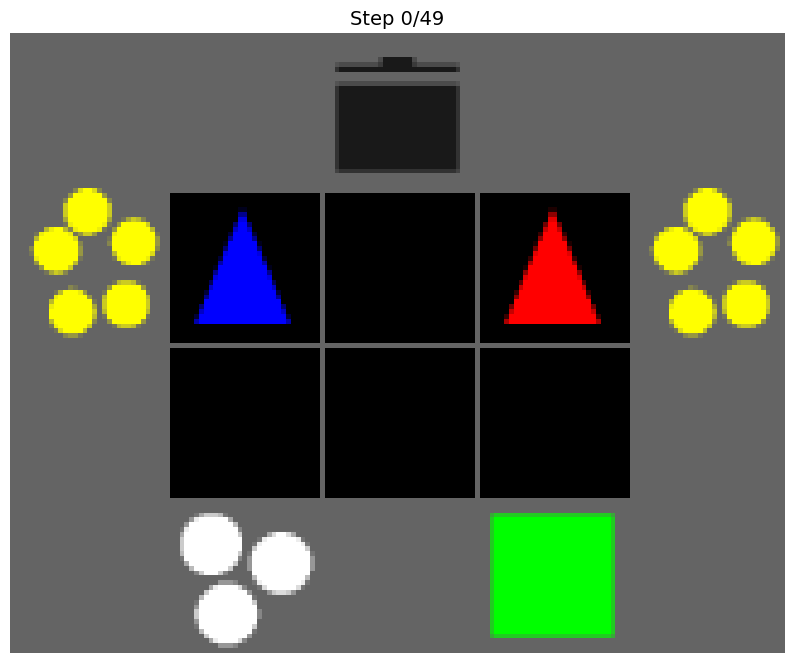

In [13]:
# Create matplotlib animation
fig, ax = plt.subplots(figsize=(10, 10))
ax.axis('off')

# Initialize with first frame
im = ax.imshow(frame_seq[0])

def update(frame):
    im.set_array(frame_seq[frame])
    ax.set_title(f'Step {frame}/{len(frame_seq)-1}', fontsize=14)
    return [im]

# Create animation
ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(frame_seq),
    blit=False,
    interval=200,  # 200ms between frames
    repeat=True
)

# Display in notebook
HTML(ani.to_html5_video())


## Save Animation as GIF (Optional)

You can also save the animation as a GIF file using the visualizer's built-in method.


In [ ]:
# Save animation as GIF (uncomment to save)
# viz.animate(state_seq, filename="overcooked_v2_animation.gif", agent_view_size=None)
# print("Animation saved as 'overcooked_v2_animation.gif'")


## Environment Elements and Recipes

This section shows all the building blocks of the OvercookedV2 environment, including static objects, dynamic objects, ingredients, and recipes.


In [14]:
from jaxmarl.environments.overcooked_v2.common import (
    StaticObject,
    DynamicObject,
    MAX_INGREDIENTS
)

print("=" * 60)
print("STATIC OBJECTS (Environment Building Blocks)")
print("=" * 60)
print("\nThese are the objects that make up the environment layout:")
for obj in StaticObject:
    print(f"  {obj.name:30s} = {obj.value}")

print("\n" + "=" * 60)
print("DYNAMIC OBJECTS (Items that can be picked up/moved)")
print("=" * 60)
print("\nThese are the items that agents can interact with:")
for obj in DynamicObject:
    if obj != DynamicObject.BASE_INGREDIENT:  # Skip base, it's used for ingredient encoding
        print(f"  {obj.name:30s} = {obj.value}")

print("\n" + "=" * 60)
print("INGREDIENTS")
print("=" * 60)
print(f"\nMaximum ingredients per recipe: {MAX_INGREDIENTS}")
print("\nIngredients are encoded using bit flags:")
print("  - Each ingredient has a unique bit pattern")
print("  - Recipe = sum of ingredient encodings")
for i in range(4):  # Show first 4 ingredients
    ingredient_encoding = DynamicObject.ingredient(i)
    print(f"  Ingredient {i}: encoding = {ingredient_encoding} (binary: {bin(ingredient_encoding)})")


STATIC OBJECTS (Environment Building Blocks)

These are the objects that make up the environment layout:
  EMPTY                          = 0
  WALL                           = 1
  AGENT                          = 2
  SELF_AGENT                     = 3
  GOAL                           = 4
  POT                            = 5
  RECIPE_INDICATOR               = 6
  BUTTON_RECIPE_INDICATOR        = 7
  PLATE_PILE                     = 9
  INGREDIENT_PILE_BASE           = 10

DYNAMIC OBJECTS (Items that can be picked up/moved)

These are the items that agents can interact with:
  EMPTY                          = 0
  PLATE                          = 1
  COOKED                         = 2

INGREDIENTS

Maximum ingredients per recipe: 3

Ingredients are encoded using bit flags:
  - Each ingredient has a unique bit pattern
  - Recipe = sum of ingredient encodings
  Ingredient 0: encoding = 4 (binary: 0b100)
  Ingredient 1: encoding = 16 (binary: 0b10000)
  Ingredient 2: encoding = 64 (binary: 

In [15]:
print("=" * 60)
print("CURRENT LAYOUT INFORMATION")
print("=" * 60)
print(f"\nLayout: {env.layout if hasattr(env, 'layout') else 'N/A'}")
print(f"Number of ingredients available: {env.layout.num_ingredients}")
print(f"\nPossible recipes for this layout:")
print(f"  Total recipes: {len(env.possible_recipes)}")

# Decode and display recipes
from jaxmarl.environments.overcooked_v2.common import DynamicObject

print("\nRecipe details:")
for idx, recipe in enumerate(env.possible_recipes):
    # Recipe is stored as a list of ingredient indices [ing0, ing1, ing2]
    recipe_encoding = DynamicObject.get_recipe_encoding(jnp.array(recipe))
    ingredient_list = DynamicObject.get_ingredient_idx_list_jit(recipe_encoding)
    # Filter out -1 values
    ingredients = [int(i) for i in ingredient_list if i != -1]
    print(f"  Recipe {idx}: {recipe} -> Ingredients: {ingredients} (encoding: {recipe_encoding})")


CURRENT LAYOUT INFORMATION

Layout: Layout(agent_positions=[(3, 1), (1, 1)], static_objects=array([[ 1,  1,  5,  1,  1],
       [10,  0,  0,  0, 10],
       [ 1,  0,  0,  0,  1],
       [ 1,  9,  1,  4,  1]]), num_ingredients=1, possible_recipes=[[0, 0, 0]])
Number of ingredients available: 1

Possible recipes for this layout:
  Total recipes: 1

Recipe details:
  Recipe 0: [0 0 0] -> Ingredients: [0, 0, 0] (encoding: 12)


In [16]:
print("=" * 60)
print("ALL AVAILABLE LAYOUTS AND THEIR RECIPES")
print("=" * 60)

for layout_name, layout in sorted(overcooked_v2_layouts.items()):
    print(f"\n{layout_name}:")
    print(f"  Grid size: {layout.width}x{layout.height}")
    print(f"  Number of agents: {len(layout.agent_positions)}")
    print(f"  Number of ingredients: {layout.num_ingredients}")
    print(f"  Possible recipes: {len(layout.possible_recipes)}")
    if len(layout.possible_recipes) <= 10:  # Only show details if not too many
        for idx, recipe in enumerate(layout.possible_recipes):
            print(f"    Recipe {idx}: {recipe}")
    else:
        print(f"    (Showing first 5 of {len(layout.possible_recipes)} recipes)")
        for idx, recipe in enumerate(layout.possible_recipes[:5]):
            print(f"    Recipe {idx}: {recipe}")


ALL AVAILABLE LAYOUTS AND THEIR RECIPES

asymm_advantages:
  Grid size: 9x5
  Number of agents: 2
  Number of ingredients: 1
  Possible recipes: 1
    Recipe 0: [0, 0, 0]

asymm_advantages_recipes_center:
  Grid size: 9x5
  Number of agents: 2
  Number of ingredients: 2
  Possible recipes: 4
    Recipe 0: [0, 0, 0]
    Recipe 1: [0, 0, 1]
    Recipe 2: [1, 1, 1]
    Recipe 3: [0, 1, 1]

asymm_advantages_recipes_left:
  Grid size: 9x5
  Number of agents: 2
  Number of ingredients: 2
  Possible recipes: 4
    Recipe 0: [0, 0, 0]
    Recipe 1: [0, 0, 1]
    Recipe 2: [1, 1, 1]
    Recipe 3: [0, 1, 1]

asymm_advantages_recipes_right:
  Grid size: 9x5
  Number of agents: 2
  Number of ingredients: 2
  Possible recipes: 4
    Recipe 0: [0, 0, 0]
    Recipe 1: [0, 0, 1]
    Recipe 2: [1, 1, 1]
    Recipe 3: [0, 1, 1]

coord_ring:
  Grid size: 5x5
  Number of agents: 2
  Number of ingredients: 1
  Possible recipes: 1
    Recipe 0: [0, 0, 0]

counter_circuit:
  Grid size: 8x5
  Number of agents

## Layout Symbols Reference

When creating custom layouts, use these symbols:


In [17]:
print("=" * 60)
print("LAYOUT SYMBOLS FOR CUSTOM LAYOUTS")
print("=" * 60)
print("""
When creating custom layouts using ASCII strings, use these symbols:

Static Objects:
  W  = Wall
  A  = Agent position
  X  = Goal (delivery location)
  P  = Pot (cooking station)
  B  = Plate pile
  R  = Recipe indicator (shows current recipe)
  L  = Button recipe indicator (can be activated)
  O  = Empty space (counter)
  
Ingredient Piles:
  0  = Ingredient pile 0
  1  = Ingredient pile 1
  2  = Ingredient pile 2
  3  = Ingredient pile 3
  ... (and so on)

Example layout:
  layout = \"\"\"
  WWPWW
  0A A1
  L   R
  WBWXW
  \"\"\"
  
  recipes = [[0,0,1], [0,1,1]]  # List of possible recipes
  # Each recipe is [ingredient0, ingredient1, ingredient2]
  # All recipes must have exactly 3 ingredients
""")


LAYOUT SYMBOLS FOR CUSTOM LAYOUTS

When creating custom layouts using ASCII strings, use these symbols:

Static Objects:
  W  = Wall
  A  = Agent position
  X  = Goal (delivery location)
  P  = Pot (cooking station)
  B  = Plate pile
  R  = Recipe indicator (shows current recipe)
  L  = Button recipe indicator (can be activated)
  O  = Empty space (counter)

Ingredient Piles:
  0  = Ingredient pile 0
  1  = Ingredient pile 1
  2  = Ingredient pile 2
  3  = Ingredient pile 3
  ... (and so on)

Example layout:
  layout = """
  WWPWW
  0A A1
  L   R
  WBWXW
  """

  recipes = [[0,0,1], [0,1,1]]  # List of possible recipes
  # Each recipe is [ingredient0, ingredient1, ingredient2]
  # All recipes must have exactly 3 ingredients



In [18]:
print("=" * 60)
print("CURRENT STATE RECIPE")
print("=" * 60)
print(f"\nCurrent recipe encoding: {state.recipe}")
print(f"Recipe as binary: {bin(state.recipe)}")

# Decode the recipe
ingredient_list = DynamicObject.get_ingredient_idx_list_jit(state.recipe)
ingredients = [int(i) for i in ingredient_list if i != -1]
print(f"Decoded ingredients: {ingredients}")

# Show which recipe from possible_recipes this matches
recipe_idx = None
for idx, possible_recipe in enumerate(env.possible_recipes):
    recipe_encoding = DynamicObject.get_recipe_encoding(jnp.array(possible_recipe))
    if recipe_encoding == state.recipe:
        recipe_idx = idx
        break

if recipe_idx is not None:
    print(f"This matches Recipe {recipe_idx} from possible_recipes: {env.possible_recipes[recipe_idx]}")
else:
    print("Note: Recipe encoding might be in a different format")


CURRENT STATE RECIPE

Current recipe encoding: 12
Recipe as binary: 0b1100
Decoded ingredients: [0, 0, 0]
This matches Recipe 0 from possible_recipes: [0 0 0]
